In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q /content/drive/MyDrive/dataset_mais/agriscan_final_v2.zip -d /content/dataset/

In [ ]:
# Cellule 1
!pip install -q timm

🖥️ Device : cuda
Found 5813 files belonging to 6 classes.
Found 1243 files belonging to 6 classes.
📂 Classes : ['Healthy', 'f_GLS', 'f_NLB', 'f_RUST', 'v_MLN', 'v_MSV']
🧠 Chargement MobileViT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

✅ Feature dim : 640
Epoch 01/50 | acc: 0.4473 | val_acc: 0.6356 | loss: 1.6560 | val_loss: 1.4817
  ✅ Sauvegardé (val_acc=0.6356)
Epoch 02/50 | acc: 0.6007 | val_acc: 0.7112 | loss: 1.4478 | val_loss: 1.2521
  ✅ Sauvegardé (val_acc=0.7112)
Epoch 03/50 | acc: 0.6454 | val_acc: 0.7434 | loss: 1.3016 | val_loss: 1.1047
  ✅ Sauvegardé (val_acc=0.7434)
Epoch 04/50 | acc: 0.6719 | val_acc: 0.7578 | loss: 1.2103 | val_loss: 1.0093
  ✅ Sauvegardé (val_acc=0.7578)
Epoch 05/50 | acc: 0.6857 | val_acc: 0.7788 | loss: 1.1601 | val_loss: 0.9374
  ✅ Sauvegardé (val_acc=0.7788)
Epoch 06/50 | acc: 0.7110 | val_acc: 0.7940 | loss: 1.1088 | val_loss: 0.8977
  ✅ Sauvegardé (val_acc=0.7940)
Epoch 07/50 | acc: 0.7339 | val_acc: 0.8053 | loss: 1.0698 | val_loss: 0.8625
  ✅ Sauvegardé (val_acc=0.8053)
Epoch 08/50 | acc: 0.7361 | val_acc: 0.8134 | loss: 1.0428 | val_loss: 0.8326
  ✅ Sauvegardé (val_acc=0.8134)
Epoch 09/50 | acc: 0.7437 | val_acc: 0.8327 | loss: 1.0216 | val_loss: 0.8113
  ✅ Sauvegardé (val_ac

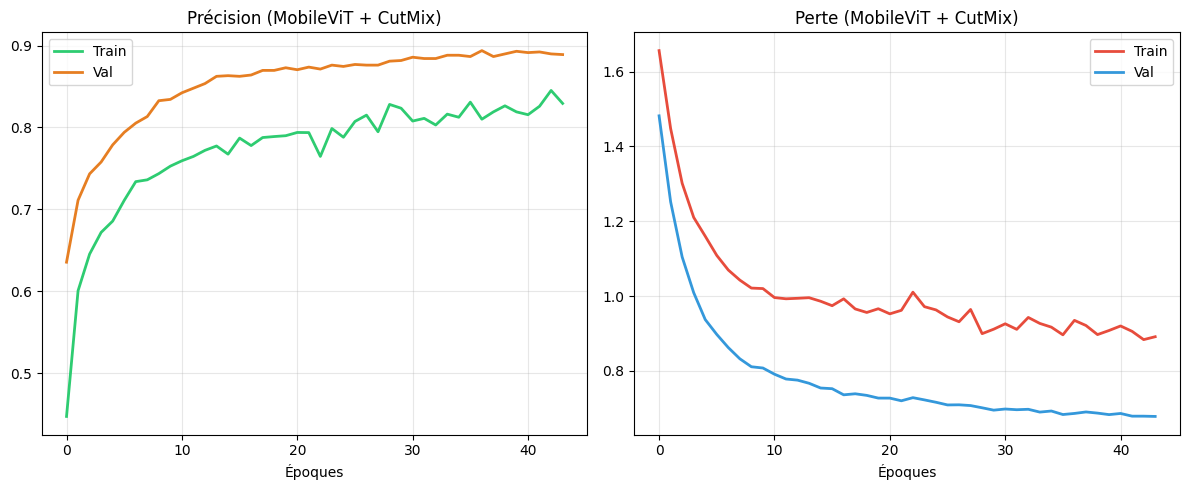

In [ ]:
# Cellule 2
import os
os.environ["KERAS_BACKEND"] = "torch"


import torch
import keras
import timm
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 6
DATA_PATH = "/content/dataset/agriscan_final_v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device : {device}")

# --- Dataset via Keras (qui utilise tf.data en interne) ---
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_PATH, 'train'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_PATH, 'val'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

CLASS_NAMES = train_ds.class_names
print(f" Classes : {CLASS_NAMES}")

def cutmix_tf(images, labels):
    B = tf.shape(images)[0]
    W, H = IMG_SIZE[0], IMG_SIZE[1]

    # Lambda aléatoire
    lam = tf.random.uniform([], 0.0, 1.0)
    cut_rat = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(W, tf.float32) * cut_rat, tf.int32)
    cut_h = tf.cast(tf.cast(H, tf.float32) * cut_rat, tf.int32)

    cx = tf.random.uniform([], 0, W, dtype=tf.int32)
    cy = tf.random.uniform([], 0, H, dtype=tf.int32)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, W)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, W)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, H)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, H)

    # Shuffle
    indices = tf.random.shuffle(tf.range(B))
    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels, indices)

    #  Masque 100% graph-compatible — pas de boucle Python
    y_range = tf.range(H)
    x_range = tf.range(W)
    y_mask = tf.cast((y_range >= y1) & (y_range < y2), tf.float32)  # (H,)
    x_mask = tf.cast((x_range >= x1) & (x_range < x2), tf.float32)  # (W,)
    mask_2d = tf.einsum('i,j->ij', y_mask, x_mask)                  # (H, W)
    mask = tf.reshape(mask_2d, [1, H, W, 1])                         # (1, H, W, 1)

    mixed = images * (1.0 - mask) + shuffled_images * mask

    lam_real = 1.0 - tf.cast((x2 - x1) * (y2 - y1), tf.float32) / tf.cast(W * H, tf.float32)
    mixed_labels = lam_real * labels + (1.0 - lam_real) * shuffled_labels

    return mixed, mixed_labels



def apply_cutmix_conditionally(images, labels):

    apply_cutmix = tf.random.uniform([]) < 0.50

    return tf.cond(
        apply_cutmix,
        lambda: cutmix_tf(images, labels),
        lambda: (images, labels) # On rend l'image normale sans rien toucher
    )

# On applique notre nouvelle fonction conditionnelle au dataset
train_ds = train_ds.map(apply_cutmix_conditionally, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# --- MobileViT (PyTorch pur) ---
print(" Chargement MobileViT...")
backbone = timm.create_model('mobilevit_s', pretrained=True, num_classes=0)
children = list(backbone.children())
for i, block in enumerate(backbone.children()):
    for param in block.parameters():
        param.requires_grad = (i >= len(children) - 2)

feature_dim = backbone.num_features
print(f" Feature dim : {feature_dim}")

class AgriScanMobileViT(torch.nn.Module):
    def __init__(self, backbone, num_classes, feature_dim):
        super().__init__()
        self.backbone = backbone
        self.drop = torch.nn.Dropout(0.4)
        self.head = torch.nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2) / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
        x = (x - mean) / std
        return self.head(self.drop(self.backbone(x)))  # logits, pas softmax

model = AgriScanMobileViT(backbone, NUM_CLASSES, feature_dim).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=0.01
)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=3
)

# --- Boucle d'entraînement ---
best_val_acc = 0
patience_counter = 0
EARLY_STOP_PATIENCE = 7
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_ds:
        images = torch.tensor(images.numpy(), dtype=torch.float32).to(device)
        labels = torch.tensor(labels.numpy(), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss    += loss.item() * len(images)
        train_correct += (outputs.argmax(1) == labels.argmax(1)).sum().item()
        train_total   += len(images)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_ds:
            images = torch.tensor(images.numpy(), dtype=torch.float32).to(device)
            labels = torch.tensor(labels.numpy(), dtype=torch.float32).to(device)
            outputs = model(images)
            val_loss    += criterion(outputs, labels).item() * len(images)
            val_correct += (outputs.argmax(1) == labels.argmax(1)).sum().item()
            val_total   += len(images)

    acc          = train_correct / train_total
    val_acc      = val_correct / val_total
    avg_tl       = train_loss / train_total
    avg_vl       = val_loss / val_total

    history["accuracy"].append(acc)
    history["val_accuracy"].append(val_acc)
    history["loss"].append(avg_tl)
    history["val_loss"].append(avg_vl)

    scheduler.step(avg_vl)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | acc: {acc:.4f} | val_acc: {val_acc:.4f} | loss: {avg_tl:.4f} | val_loss: {avg_vl:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': CLASS_NAMES,
            'val_acc': val_acc
        }, "/content/drive/MyDrive/agriscan_mobilevit_best.pt")
        print(f"   Sauvegardé (val_acc={val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping !")
            break

print(f"\n Meilleure val_acc : {best_val_acc:.4f}")

# --- Courbes ---
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(history["accuracy"],     label="Train", color="#2ecc71", lw=2)
plt.plot(history["val_accuracy"], label="Val",   color="#e67e22", lw=2)
plt.title("Précision (MobileViT + CutMix)")
plt.xlabel("Époques"); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history["loss"],     label="Train", color="#e74c3c", lw=2)
plt.plot(history["val_loss"], label="Val",   color="#3498db", lw=2)
plt.title("Perte (MobileViT + CutMix)")
plt.xlabel("Époques"); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/courbes_mobilevit.png", dpi=150)
plt.show()

🖥️ Device : cuda
Found 5813 files belonging to 6 classes.
Found 1243 files belonging to 6 classes.
📦 Chargement du meilleur modèle Phase 1...
✅ Chargé — val_acc Phase 1 : 0.8938
🔓 Dégel des derniers blocs MobileViT...
   → 4,941,014 / 4,941,478 paramètres dégelés (100.0%)

🔥 Phase 2 — Fine-Tuning (30 epochs)...

Epoch 01/30 | acc: 0.9062 | val_acc: 0.9147 | loss: 0.6668 | val_loss: 0.6473
  ✅ Nouveau record ! Sauvegardé (val_acc=0.9147)
Epoch 02/30 | acc: 0.9234 | val_acc: 0.9212 | loss: 0.6307 | val_loss: 0.6282
  ✅ Nouveau record ! Sauvegardé (val_acc=0.9212)
Epoch 03/30 | acc: 0.9410 | val_acc: 0.9284 | loss: 0.6019 | val_loss: 0.6151
  ✅ Nouveau record ! Sauvegardé (val_acc=0.9284)
Epoch 04/30 | acc: 0.9443 | val_acc: 0.9324 | loss: 0.5930 | val_loss: 0.6038
  ✅ Nouveau record ! Sauvegardé (val_acc=0.9324)
Epoch 05/30 | acc: 0.9536 | val_acc: 0.9381 | loss: 0.5748 | val_loss: 0.5962
  ✅ Nouveau record ! Sauvegardé (val_acc=0.9381)
Epoch 06/30 | acc: 0.9575 | val_acc: 0.9397 | loss:

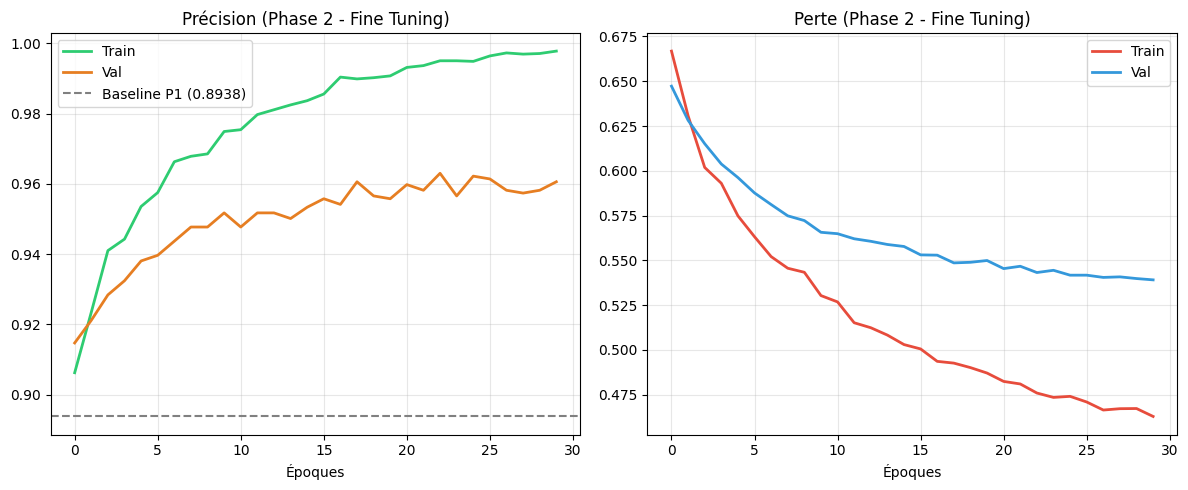

📊 Courbes sauvegardées !


In [ ]:
# Cellule 1 — Imports
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import timm
import torch.nn as nn
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_P2 = 30
NUM_CLASSES = 6
DATA_PATH = "/content/dataset/agriscan_final_v2"
CLASS_NAMES = ['Healthy', 'f_GLS', 'f_NLB', 'f_RUST', 'v_MLN', 'v_MSV']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device : {device}")

# --- Dataset ---
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_PATH, 'train'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
).prefetch(tf.data.AUTOTUNE)

val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_PATH, 'val'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
).prefetch(tf.data.AUTOTUNE)

# --- Reconstruction du modèle (même architecture que Phase 1) ---
backbone = timm.create_model('mobilevit_s', pretrained=False, num_classes=0)
feature_dim = backbone.num_features

class AgriScanMobileViT(nn.Module):
    def __init__(self, backbone, num_classes, feature_dim):
        super().__init__()
        self.backbone = backbone
        self.drop = nn.Dropout(0.4)
        self.head = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2) / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
        x = (x - mean) / std
        return self.head(self.drop(self.backbone(x)))

model = AgriScanMobileViT(backbone, NUM_CLASSES, feature_dim).to(device)

# --- Chargement du checkpoint Phase 1 ---
print(" Chargement du meilleur modèle Phase 1...")
checkpoint = torch.load("/content/drive/MyDrive/agriscan_mobilevit_best.pt", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Chargé — val_acc Phase 1 : {checkpoint['val_acc']:.4f}")

# --- DÉGEL Phase 2 ---
print("Dégel des derniers blocs MobileViT...")

# On gèle tout d'abord
for param in model.parameters():
    param.requires_grad = False

# On dégèle la tête
for param in model.head.parameters():
    param.requires_grad = True
for param in model.drop.parameters():
    param.requires_grad = True

# On dégèle les 3 derniers blocs du backbone
children = list(model.backbone.children())
for block in children[-3:]:
    for param in block.parameters():
        param.requires_grad = True

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   → {trainable:,} / {total:,} paramètres dégelés ({trainable/total*100:.1f}%)")

# --- Optimizer Phase 2 : LR très faible ---
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,  # 10x plus petit qu'en Phase 1
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=3
)

# --- Boucle Phase 2 ---
best_val_acc = checkpoint['val_acc']  # On part du meilleur de Phase 1
patience_counter = 0
EARLY_STOP_PATIENCE = 7
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

print(f"\n🔥 Phase 2 — Fine-Tuning ({EPOCHS_P2} epochs)...\n")

for epoch in range(EPOCHS_P2):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_ds:
        images = torch.tensor(images.numpy(), dtype=torch.float32).to(device)
        labels = torch.tensor(labels.numpy(), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss    += loss.item() * len(images)
        train_correct += (outputs.argmax(1) == labels.argmax(1)).sum().item()
        train_total   += len(images)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_ds:
            images = torch.tensor(images.numpy(), dtype=torch.float32).to(device)
            labels = torch.tensor(labels.numpy(), dtype=torch.float32).to(device)
            outputs = model(images)
            val_loss    += criterion(outputs, labels).item() * len(images)
            val_correct += (outputs.argmax(1) == labels.argmax(1)).sum().item()
            val_total   += len(images)

    acc     = train_correct / train_total
    val_acc = val_correct / val_total
    avg_tl  = train_loss / train_total
    avg_vl  = val_loss / val_total

    history["accuracy"].append(acc)
    history["val_accuracy"].append(val_acc)
    history["loss"].append(avg_tl)
    history["val_loss"].append(avg_vl)

    scheduler.step(avg_vl)
    print(f"Epoch {epoch+1:02d}/{EPOCHS_P2} | acc: {acc:.4f} | val_acc: {val_acc:.4f} | loss: {avg_tl:.4f} | val_loss: {avg_vl:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': CLASS_NAMES,
            'val_acc': val_acc
        }, "/content/drive/MyDrive/agriscan_mobilevit_FINAL.pt")
        print(f"   Nouveau record ! Sauvegardé (val_acc={val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"⏹Early stopping !")
            break

print(f"\ Meilleure val_acc Phase 2 : {best_val_acc:.4f}")

# --- Courbes ---
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(history["accuracy"],     label="Train", color="#2ecc71", lw=2)
plt.plot(history["val_accuracy"], label="Val",   color="#e67e22", lw=2)
plt.axhline(y=checkpoint['val_acc'], color='gray', linestyle='--', label=f"Baseline P1 ({checkpoint['val_acc']:.4f})")
plt.title("Précision (Phase 2 - Fine Tuning)")
plt.xlabel("Époques"); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history["loss"],     label="Train", color="#e74c3c", lw=2)
plt.plot(history["val_loss"], label="Val",   color="#3498db", lw=2)
plt.title("Perte (Phase 2 - Fine Tuning)")
plt.xlabel("Époques"); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/courbes_mobilevit_p2.png", dpi=150)
plt.show()
print("Courbes sauvegardées !")

In [ ]:
import torch
import timm
import torch.nn as nn
import os
import subprocess

# --- 1. Redéfinition exacte de ton architecture ---
backbone = timm.create_model('mobilevit_s', pretrained=False, num_classes=0)
feature_dim = backbone.num_features

class AgriScanMobileViT(nn.Module):
    def __init__(self, backbone, num_classes, feature_dim):
        super().__init__()
        self.backbone = backbone
        self.drop = nn.Dropout(0.4)
        self.head = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        # /!\ TRÈS IMPORTANT pour l'application mobile :
        # Ton modèle PyTorch s'attend à une image [Batch, Canaux, Hauteur, Largeur]
        # et applique la normalisation ImageNet à l'intérieur du forward.
        x = x.permute(0, 3, 1, 2) / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
        x = (x - mean) / std
        return self.head(self.drop(self.backbone(x)))

# --- 2. Initialisation et chargement des poids de la Phase 2 ---
print("🔄 Chargement du modèle de la Phase 2...")
model = AgriScanMobileViT(backbone, num_classes=6, feature_dim=feature_dim)
checkpoint = torch.load("/content/drive/MyDrive/agriscan_mobilevit_FINAL.pt", map_location="cpu")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # On fige le comportement pour l'export

# --- 3. Création du Dummy Input ---
# Attention : comme ton forward prend l'image du dataset Keras qui est en [Batch, H, W, C],
# le dummy input doit faire (1, 224, 224, 3) ! C'est parfait pour le mobile !
dummy_input = torch.randn(1, 224, 224, 3)

# --- 4. Export intermédiaire ONNX ---
onnx_path = "agriscan_mobilevit.onnx"
print("📦 Étape 1 : Exportation vers ONNX (Opset 18)...")
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=18,          # 👈 On passe à 18 ici pour éviter le crash du 'Resize'
    do_constant_folding=True,
    input_names=['input_image'],
    output_names=['preds_output'],
)
print("✅ Fichier intermédiaire ONNX généré.")
# --- 5. Conversion ONNX vers TFLite (Float32 pur) ---
print("🚀 Étape 2 : Conversion vers TFLite (Float32)...")
try:
    # On exécute avec check=True pour bloquer proprement en cas d'erreur interne
    subprocess.run(["onnx2tf", "-i", onnx_path, "-o", "tflite_output"], check=True)

    src_tflite = os.path.join("tflite_output", "model_float32.tflite")
    final_tflite = "/content/drive/MyDrive/agriscan_mobilevit_float32.tflite"

    if os.path.exists(src_tflite):
        import shutil
        shutil.copy(src_tflite, final_tflite)
        print(f"\n🎉 EXCELLENT ! Ton fichier TFLite est prêt et sauvegardé sur ton Drive :")
        print(f"👉 {final_tflite}")
    else:
        print("⚠️ Fichier introuvable dans le dossier de sortie 'tflite_output'.")
except subprocess.CalledProcessError as e:
    print(f"❌ Erreur critique lors de l'exécution d'onnx2tf. Code de retour : {e.returncode}")
except Exception as e:
    print(f"❌ Autre erreur : {e}")

🔄 Chargement du modèle de la Phase 2...
📦 Étape 1 : Exportation vers ONNX (Opset 18)...
[torch.onnx] Obtain model graph for `AgriScanMobileViT([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `AgriScanMobileViT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 67 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
✅ Fichier intermédiaire ONNX généré.
🚀 Étape 2 : Conversion vers TFLite (Float32)...
⚠️ Fichier introuvable dans le dossier de sortie 'tflite_output'.


In [ ]:
!onnx2tf -i agriscan_mobilevit.onnx -o tflite_output


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃                    ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add                │ 56             │ 56               │
│ Concat             │ 3              │ 3                │
│ Constant           │ 223            │ 223              │
│ Conv               │ 35             │ 35               │
│ Div                │ 2              │ 2                │
│ Gemm               │ 1              │ 1                │
│ LayerNormalization │ 21             │ 21               │
│ MatMul             │ 54             │ 54               │
│ Mul                │ 52             │ 52               │
│ ReduceMean         │ 1              │ 1                │
│ Reshape            │ 55             │ 55               │
│ Resize             │ 2              │ 

In [ ]:
!pip install onnx2tf tensorflow

In [ ]:
import shutil
from google.colab import drive

# On monte le drive (si ce n'est pas déjà fait)
drive.mount('/content/drive')

# Copie du Float32
shutil.copy("tflite_output/agriscan_mobilevit_float32.tflite", "/content/drive/MyDrive/agriscan_mobilevit_float32.tflite")

# Copie du Float16
shutil.copy("tflite_output/agriscan_mobilevit_float16.tflite", "/content/drive/MyDrive/agriscan_mobilevit_float16.tflite")

print("💾 Les deux modèles ont été sauvegardés à la racine de ton Google Drive ! Tu peux les télécharger sur ton PC.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
💾 Les deux modèles ont été sauvegardés à la racine de ton Google Drive ! Tu peux les télécharger sur ton PC.
